# AI Risk Manager — EDA
## Phase 2: Fraud Transaction Scorer

Explores `data/raw/transactions.csv` before model training.

Goals:
- Understand class balance (fraud vs legitimate)
- Verify fraud signals are visible in the data
- Find which features separate fraud from legit most clearly
- Check for missing values or data quality issues


---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/raw/transactions.csv')
print(f'Shape  : {df.shape}')
print(f'Columns: {len(df.columns)}')
df.head(3)


Shape  : (10000, 38)
Columns: 38


,transaction_id,customer_id,merchant_id,order_value,product_category,payment_method,transaction_datetime,hour_of_day,day_of_week,device_id,...,is_new_account,address_mismatch,multiple_failed_attempts,high_velocity_1h,order_value_normalized,new_account_high_value_card,payment_risk_score,category_risk_score,fraud_pattern,is_fraud
0,T_06253,C_11632,M_5054,976.33,home,upi,2026-03-22 13:52:15,13,6,DEV_3281,...,0,0,0,0,0.4207,0,0.3,0.30,none,False
1,T_04685,C_10457,M_5076,3682.28,luxury,card,2026-03-12 17:03:15,17,3,DEV_8015,...,0,0,0,0,2.0875,0,0.9,0.85,none,False
2,T_01732,C_10126,M_5076,2039.10,gift_cards,card,2026-03-09 19:58:15,19,0,DEV_8699,...,0,0,0,0,1.1203,0,0.9,0.90,none,False


---
## 2. Basic Info

In [2]:
print('=== Data Types ===')
print(df.dtypes)
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None')


=== Data Types ===
transaction_id                     str
customer_id                        str
merchant_id                        str
order_value                    float64
product_category                   str
payment_method                     str
transaction_datetime               str
hour_of_day                      int64
day_of_week                      int64
device_id                          str
transaction_city                   str
billing_city                       str
shipping_city                      str
failed_attempts                  int64
is_vpn                           int64
customer_account_age_days        int64
customer_total_past_orders       int64
customer_avg_order_value       float64
customer_past_fraud_flags        int64
customer_orders_1h               int64
customer_orders_24h              int64
merchant_fraud_rate            float64
is_night_transaction             int64
is_weekend                       int64
is_new_device                    int64
is_dif

---
## 3. Class Balance

Expected: ~85% legitimate (0), ~15% fraudulent (1)


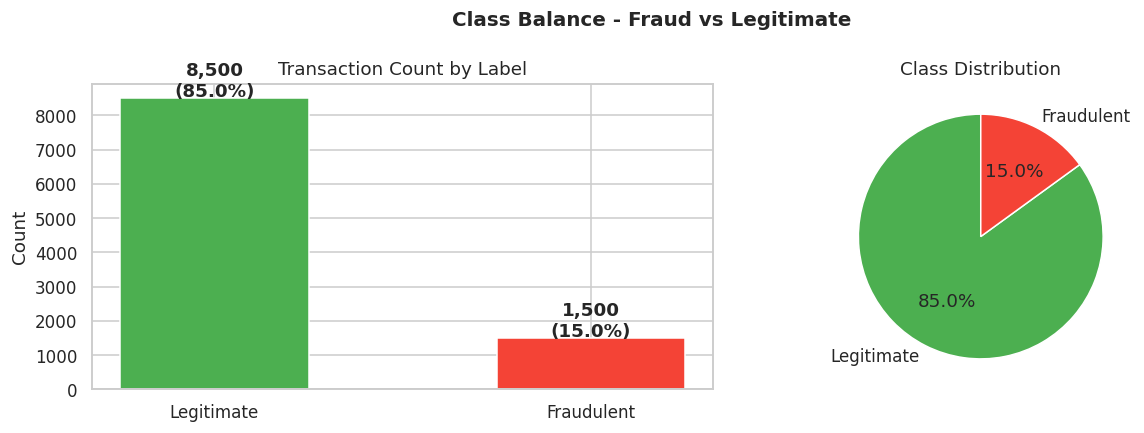

Legitimate : 8,500  (85.0%)
Fraudulent : 1,500  (15.0%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['is_fraud'].value_counts()
n_legit = counts[False]
n_fraud = counts[True]
labels = ['Legitimate', 'Fraudulent']
colors = ['#4CAF50', '#F44336']
vals = [n_legit, n_fraud]
axes[0].bar(labels, vals, color=colors, width=0.5)
axes[0].set_title('Transaction Count by Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(vals):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(vals, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution')
plt.suptitle('Class Balance - Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Legitimate : {n_legit:,}  ({n_legit/len(df)*100:.1f}%)')
print(f'Fraudulent : {n_fraud:,}  ({n_fraud/len(df)*100:.1f}%)')


---
## 4. Fraud Pattern Breakdown

Which of the 4 fraud patterns is most common?


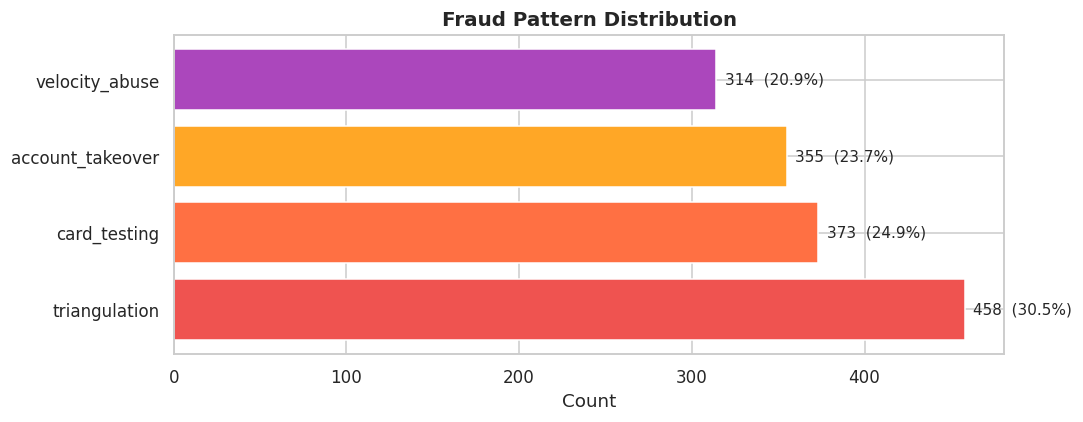

In [4]:
fraud_df = df[df['is_fraud'] == True]
pattern_counts = fraud_df['fraud_pattern'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
palette = ['#EF5350', '#FF7043', '#FFA726', '#AB47BC']
bars = ax.barh(pattern_counts.index, pattern_counts.values, color=palette)
ax.set_title('Fraud Pattern Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
for bar, val in zip(bars, pattern_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(fraud_df)*100:.1f}%)', va='center', fontsize=10)
plt.tight_layout()
plt.show()


---
## 5. Key Feature Comparison: Fraud vs Legitimate

Are our fraud signals actually visible in the data?


In [5]:
legit = df[df['is_fraud'] == False]
fraud = df[df['is_fraud'] == True]

numeric_features = [
    'order_value', 'failed_attempts', 'customer_orders_1h',
    'customer_orders_24h', 'customer_account_age_days',
    'customer_total_past_orders', 'order_value_normalized', 'hour_of_day',
]

print(f"{'Feature':<35} {'Legit Mean':<15} {'Fraud Mean':<15} {'Diff %':<10}")
print('-' * 75)
for f in numeric_features:
    lm = legit[f].mean()
    fm = fraud[f].mean()
    diff = ((fm - lm) / lm * 100) if lm != 0 else 0
    print(f'{f:<35} {lm:<15.2f} {fm:<15.2f} {diff:+.1f}%')


Feature                             Legit Mean      Fraud Mean      Diff %    
---------------------------------------------------------------------------
order_value                         4570.68         12709.92        +178.1%
failed_attempts                     0.39            2.25            +469.5%
customer_orders_1h                  0.49            6.02            +1122.5%
customer_orders_24h                 1.99            8.57            +330.4%
customer_account_age_days           945.15          266.68          -71.8%
customer_total_past_orders          52.73           15.56           -70.5%
order_value_normalized              1.53            3.08            +101.7%
hour_of_day                         15.00           11.30           -24.6%


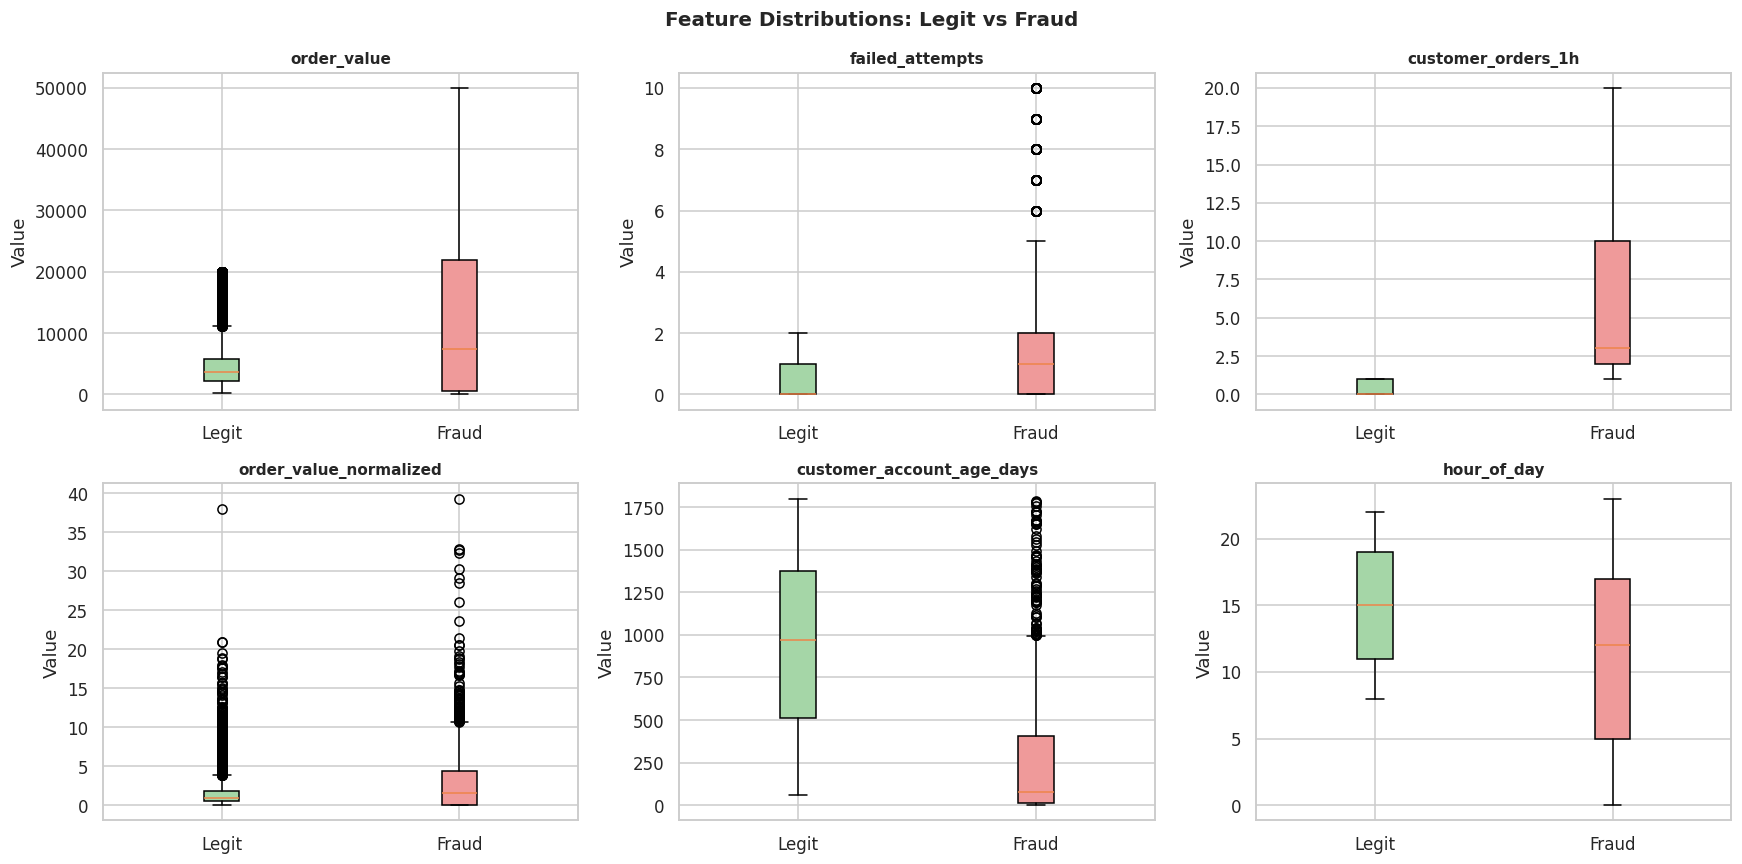

In [6]:
features_to_plot = [
    'order_value', 'failed_attempts',
    'customer_orders_1h', 'order_value_normalized',
    'customer_account_age_days', 'hour_of_day',
]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    data = [legit[feat].values, fraud[feat].values]
    bp = axes[i].boxplot(data, labels=['Legit', 'Fraud'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#A5D6A7')
    bp['boxes'][1].set_facecolor('#EF9A9A')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
plt.suptitle('Feature Distributions: Legit vs Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Binary Feature Rates

What % of fraud vs legit has each boolean flag set? Large gap = strong signal.


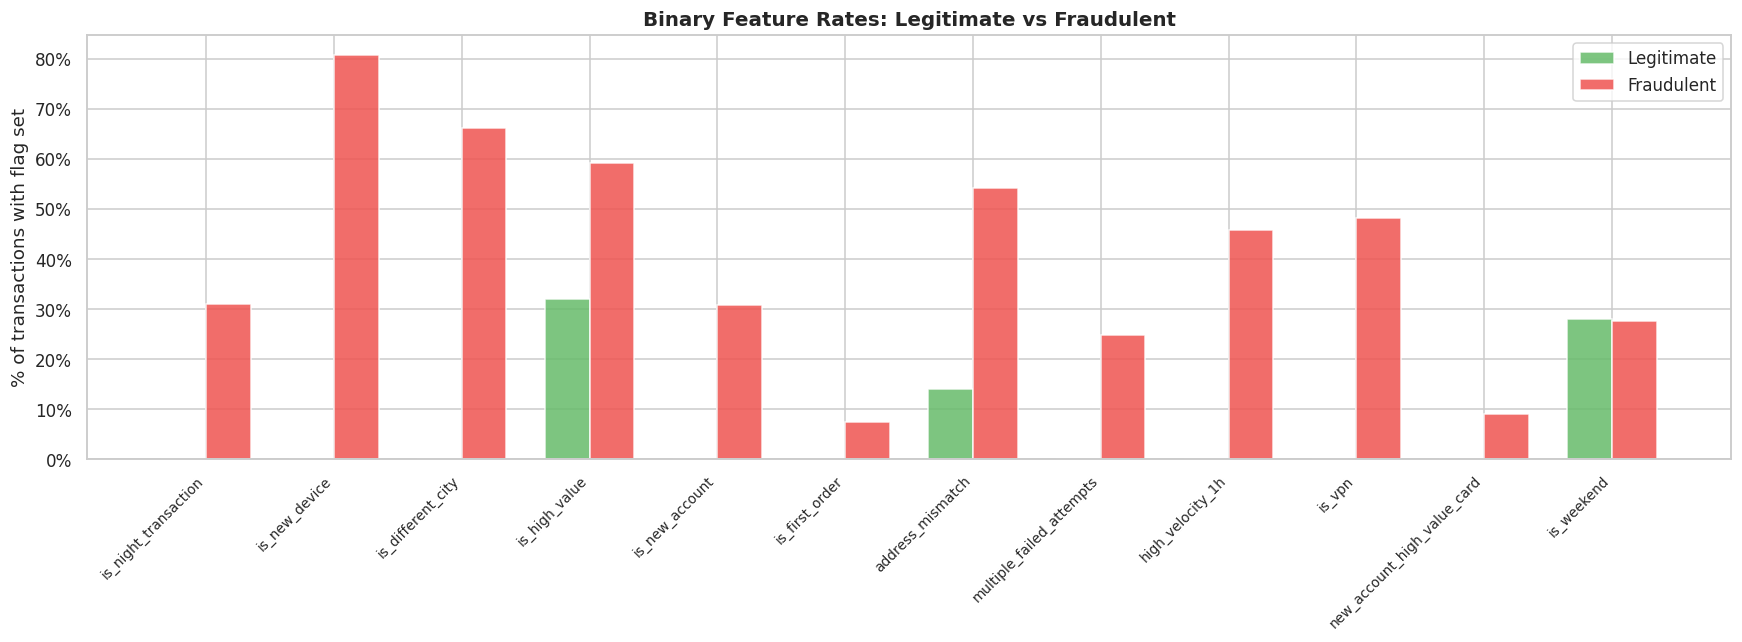

Feature                             Legit %      Fraud %      Gap       
----------------------------------------------------------------------
is_new_device                       0.0          80.8         +80.8
is_different_city                   0.0          66.3         +66.3
is_vpn                              0.0          48.3         +48.3
high_velocity_1h                    0.0          45.8         +45.8
address_mismatch                    14.0         54.2         +40.2
is_night_transaction                0.0          30.9         +30.9
is_new_account                      0.0          30.8         +30.8
is_high_value                       32.0         59.1         +27.1
multiple_failed_attempts            0.0          24.9         +24.9
new_account_high_value_card         0.0          9.1          +9.1
is_first_order                      0.0          7.5          +7.5
is_weekend                          28.1         27.5         -0.5


In [7]:
binary_features = [
    'is_night_transaction', 'is_new_device', 'is_different_city',
    'is_high_value', 'is_new_account', 'is_first_order',
    'address_mismatch', 'multiple_failed_attempts',
    'high_velocity_1h', 'is_vpn', 'new_account_high_value_card', 'is_weekend',
]
legit_rates = [legit[f].mean() * 100 for f in binary_features]
fraud_rates = [fraud[f].mean() * 100 for f in binary_features]
x = np.arange(len(binary_features))
width = 0.35
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, legit_rates, width, label='Legitimate', color='#66BB6A', alpha=0.85)
ax.bar(x + width/2, fraud_rates, width, label='Fraudulent', color='#EF5350', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(binary_features, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% of transactions with flag set')
ax.set_title('Binary Feature Rates: Legitimate vs Fraudulent', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

print(f"{'Feature':<35} {'Legit %':<12} {'Fraud %':<12} {'Gap':<10}")
print('-' * 70)
for f, lr, fr in sorted(zip(binary_features, legit_rates, fraud_rates),
                         key=lambda x: abs(x[2]-x[1]), reverse=True):
    print(f'{f:<35} {lr:<12.1f} {fr:<12.1f} {fr-lr:+.1f}')


---
## 7. Payment Method & Category by Label


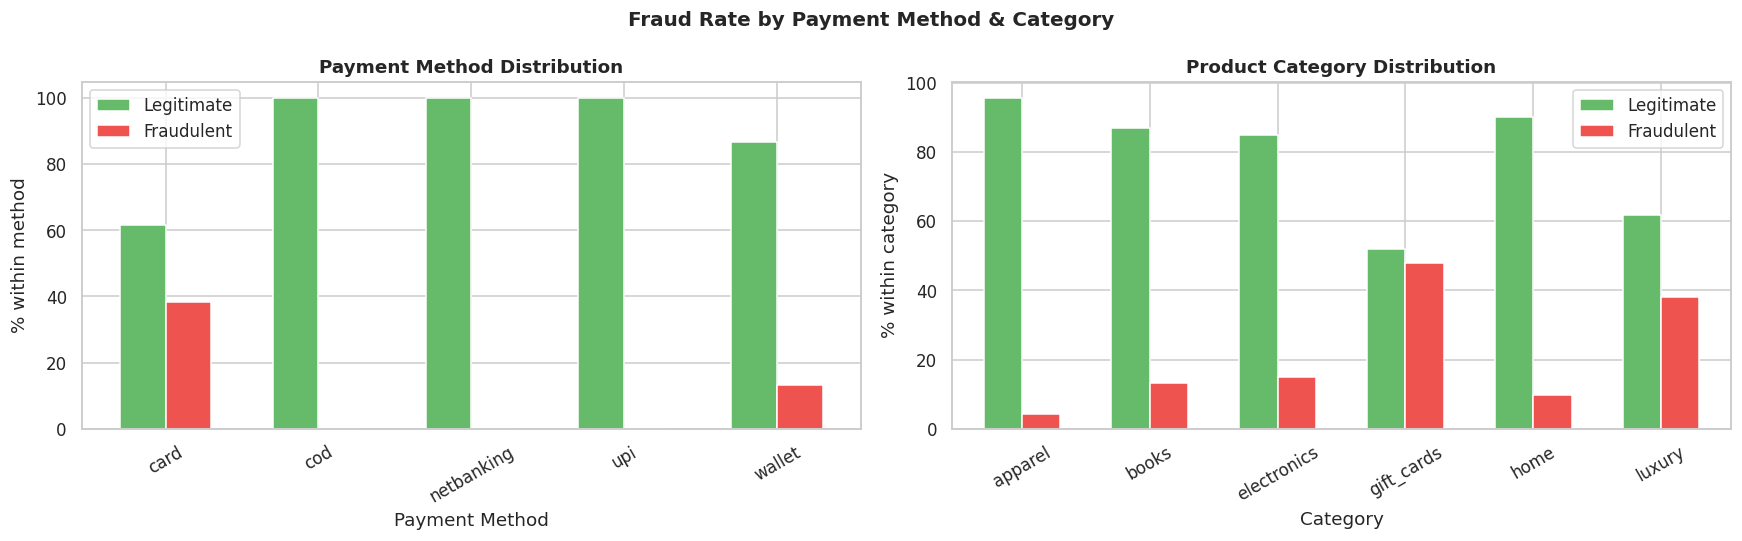

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pay_data = df.groupby(['payment_method', 'is_fraud']).size().unstack(fill_value=0)
pay_data.columns = ['Legitimate', 'Fraudulent']
pay_pct = pay_data.div(pay_data.sum(axis=1), axis=0) * 100
pay_pct.plot(kind='bar', ax=axes[0], color=['#66BB6A', '#EF5350'], width=0.6)
axes[0].set_title('Payment Method Distribution', fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('% within method')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()
cat_data = df.groupby(['product_category', 'is_fraud']).size().unstack(fill_value=0)
cat_data.columns = ['Legitimate', 'Fraudulent']
cat_pct = cat_data.div(cat_data.sum(axis=1), axis=0) * 100
cat_pct.plot(kind='bar', ax=axes[1], color=['#66BB6A', '#EF5350'], width=0.6)
axes[1].set_title('Product Category Distribution', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('% within category')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
plt.suptitle('Fraud Rate by Payment Method & Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8. Transaction Time Analysis

Fraudsters prefer off-hours — do we see this in the data?


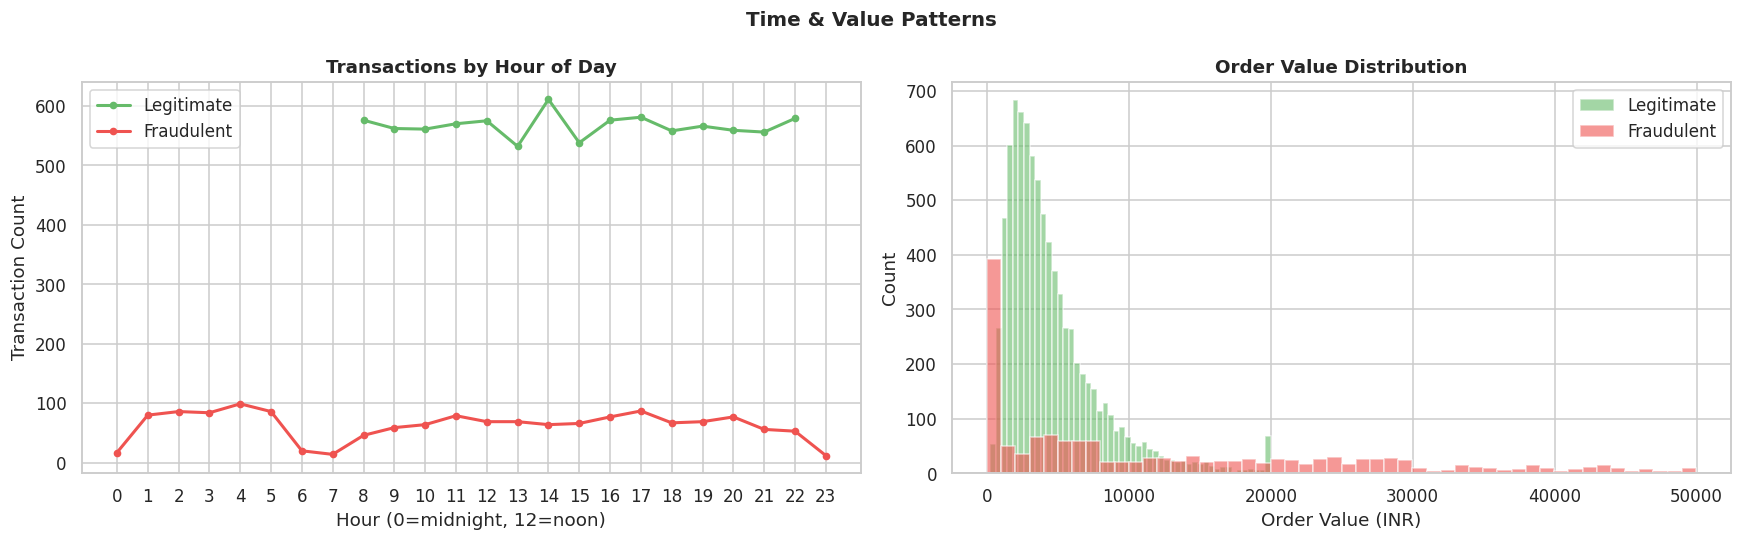

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
legit_hours = legit['hour_of_day'].value_counts().sort_index()
fraud_hours = fraud['hour_of_day'].value_counts().sort_index()
axes[0].plot(legit_hours.index, legit_hours.values, label='Legitimate',
             color='#66BB6A', linewidth=2, marker='o', markersize=4)
axes[0].plot(fraud_hours.index, fraud_hours.values, label='Fraudulent',
             color='#EF5350', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Transactions by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0=midnight, 12=noon)')
axes[0].set_ylabel('Transaction Count')
axes[0].legend()
axes[0].set_xticks(range(0, 24))
axes[1].hist(legit['order_value'], bins=50, alpha=0.6, label='Legitimate', color='#66BB6A')
axes[1].hist(fraud['order_value'], bins=50, alpha=0.6, label='Fraudulent', color='#EF5350')
axes[1].set_title('Order Value Distribution', fontweight='bold')
axes[1].set_xlabel('Order Value (INR)')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.suptitle('Time & Value Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 9. Correlation Heatmap

Which features are most correlated with `is_fraud`?


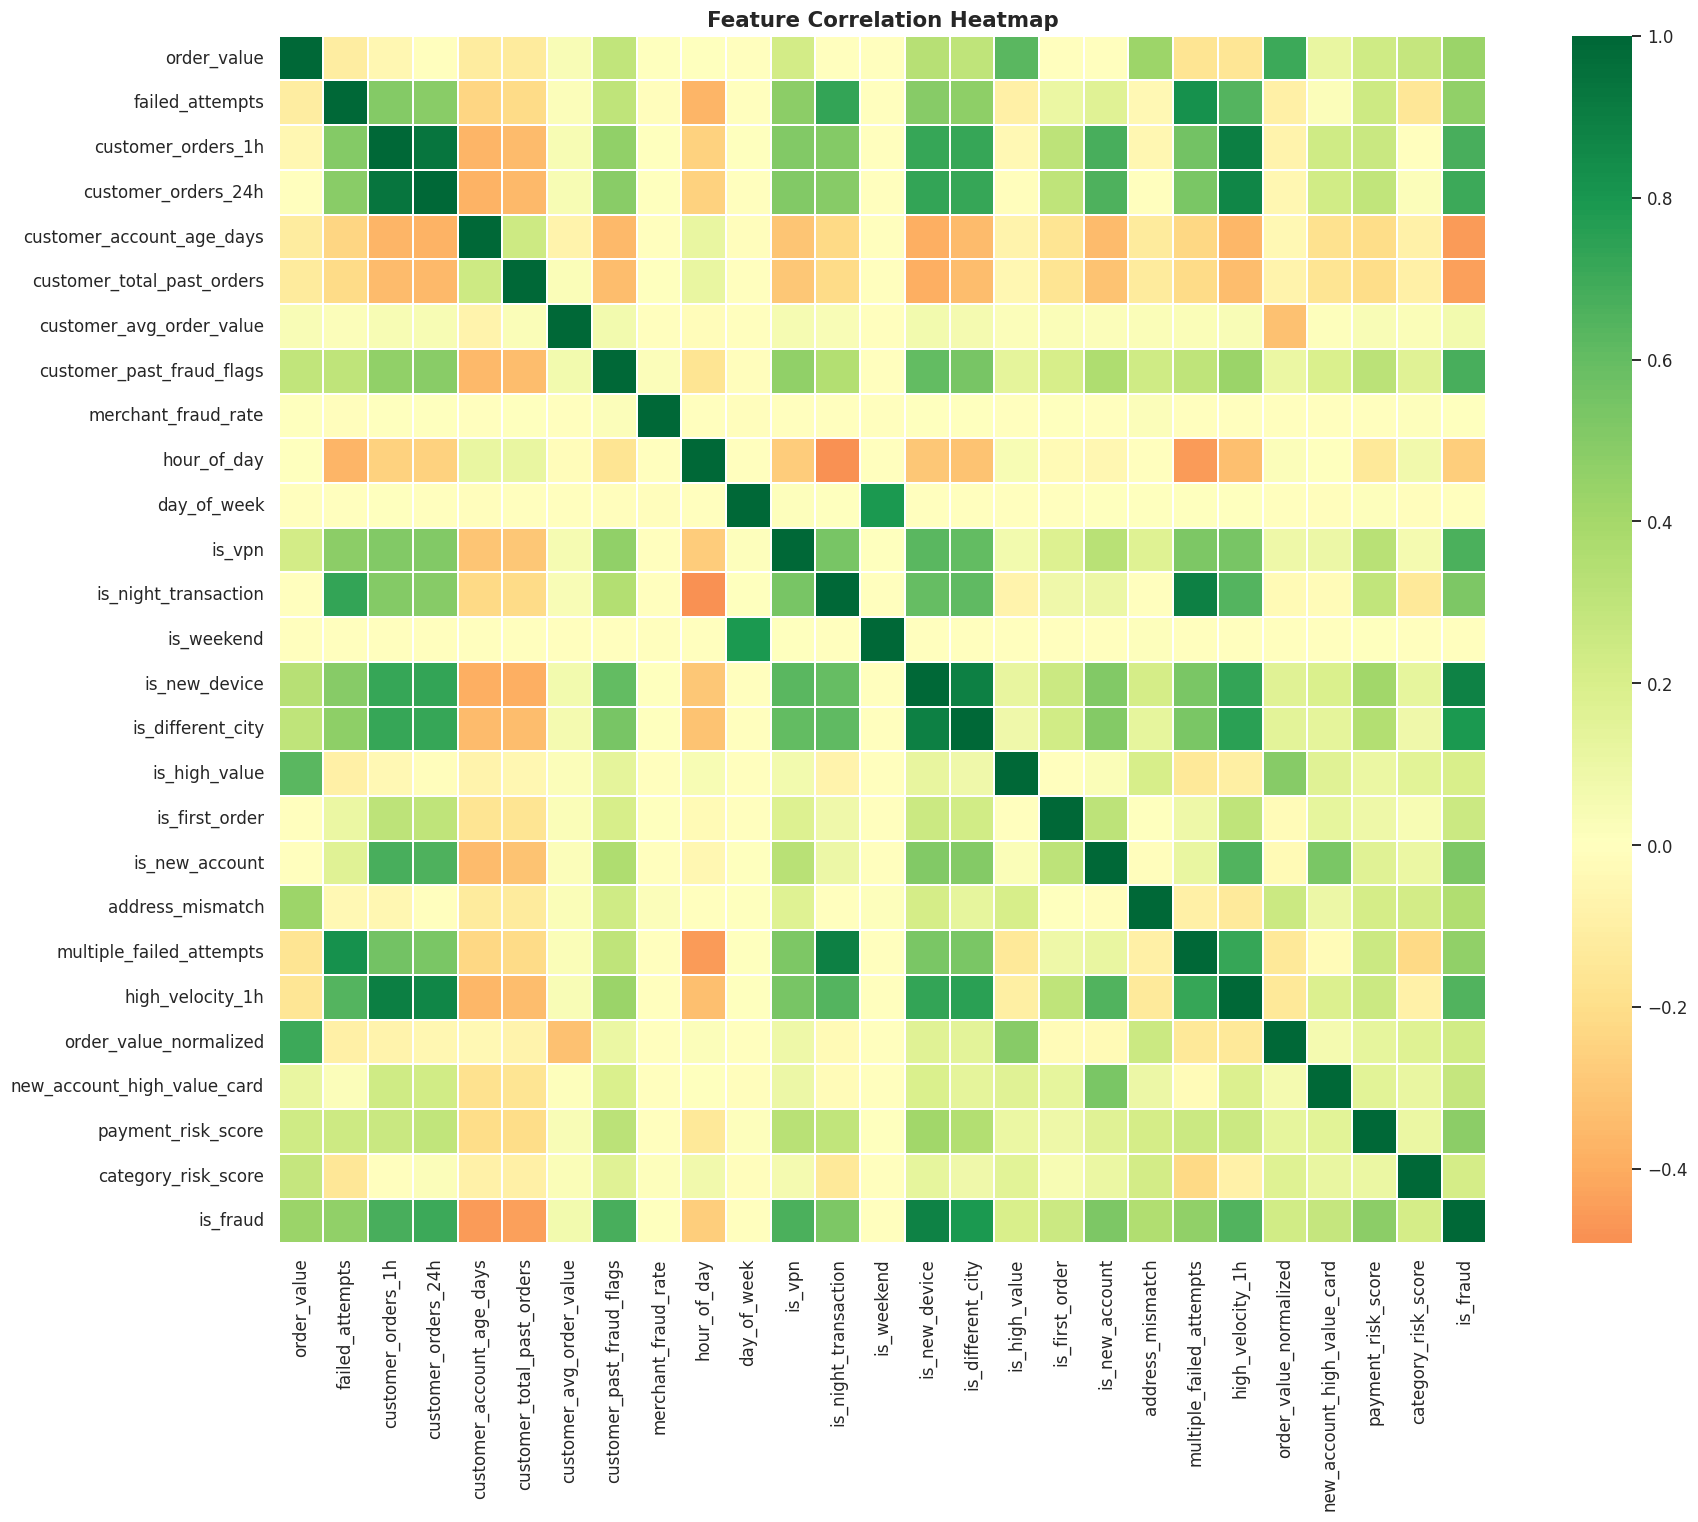

Top correlations with is_fraud:
  is_new_device                       +0.8840
  is_different_city                   +0.7908
  customer_orders_24h                 +0.7054
  customer_past_fraud_flags           +0.6731
  customer_orders_1h                  +0.6729
  is_vpn                              +0.6650
  high_velocity_1h                    +0.6465
  is_night_transaction                +0.5251
  is_new_account                      +0.5239
  payment_risk_score                  +0.4800
  multiple_failed_attempts            +0.4686
  failed_attempts                     +0.4682
  customer_account_age_days           -0.4519
  customer_total_past_orders          -0.4385
  order_value                         +0.4337


In [10]:
model_features = [
    'order_value', 'failed_attempts', 'customer_orders_1h',
    'customer_orders_24h', 'customer_account_age_days',
    'customer_total_past_orders', 'customer_avg_order_value',
    'customer_past_fraud_flags', 'merchant_fraud_rate',
    'hour_of_day', 'day_of_week', 'is_vpn',
    'is_night_transaction', 'is_weekend', 'is_new_device',
    'is_different_city', 'is_high_value', 'is_first_order',
    'is_new_account', 'address_mismatch', 'multiple_failed_attempts',
    'high_velocity_1h', 'order_value_normalized',
    'new_account_high_value_card', 'payment_risk_score',
    'category_risk_score', 'is_fraud',
]
corr = df[model_features].corr()
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, annot=False, cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with is_fraud:')
fraud_corr = corr['is_fraud'].drop('is_fraud').abs().sort_values(ascending=False)
for feat, val in fraud_corr.head(15).items():
    direction = '+' if corr['is_fraud'][feat] > 0 else '-'
    print(f'  {feat:<35} {direction}{val:.4f}')


---
## 10. Numeric Feature Distributions


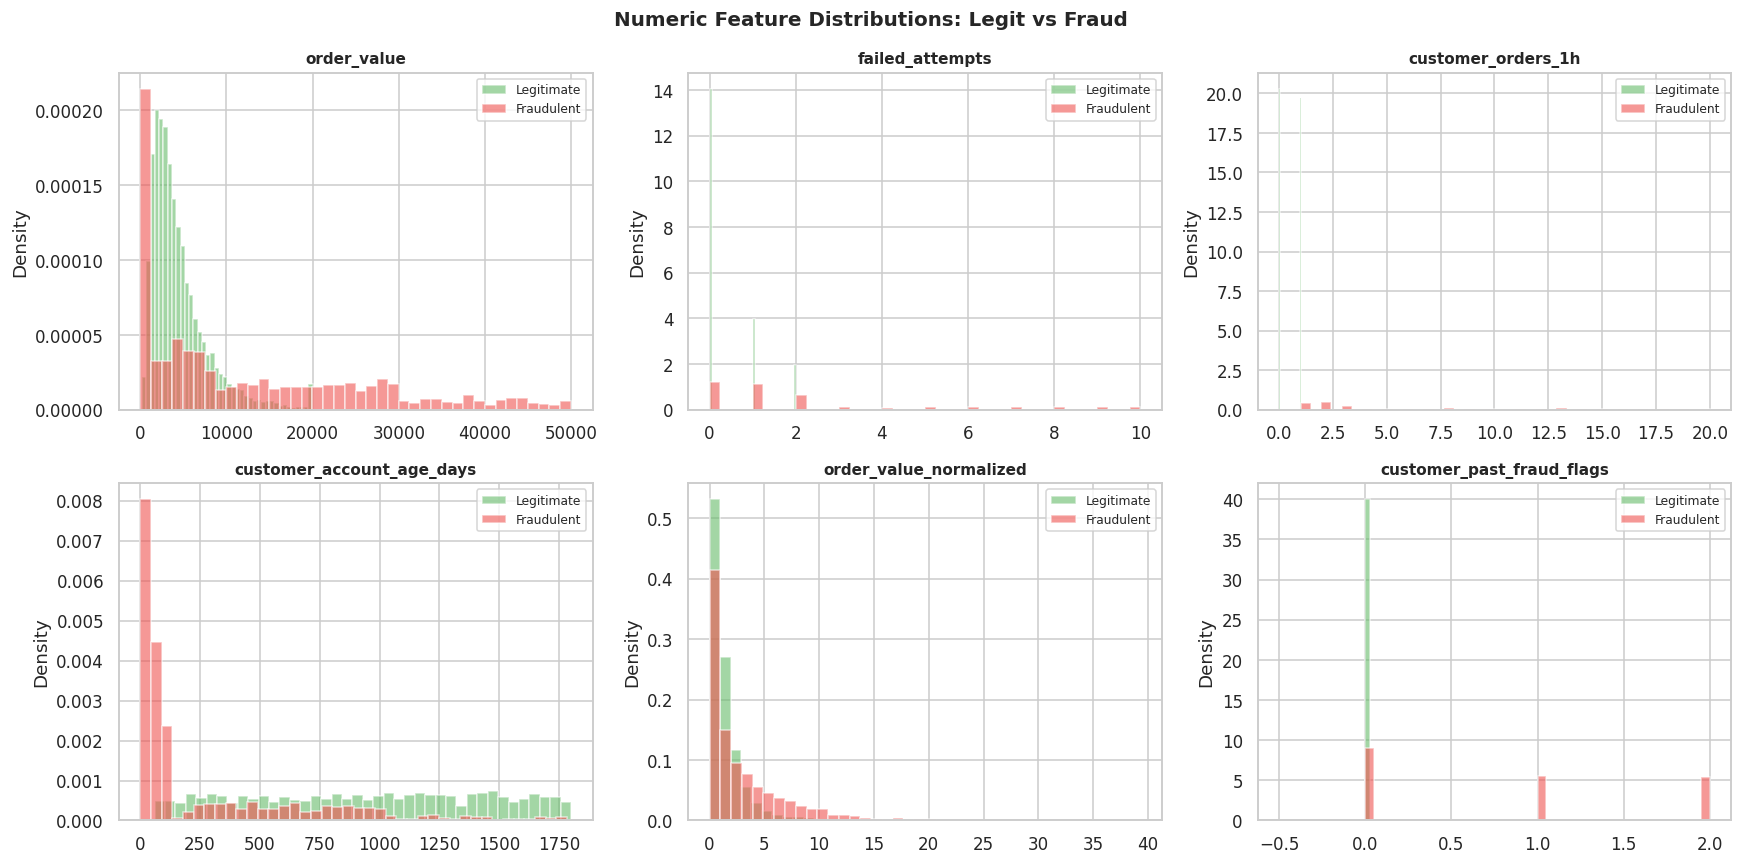

In [11]:
dist_features = [
    'order_value', 'failed_attempts',
    'customer_orders_1h', 'customer_account_age_days',
    'order_value_normalized', 'customer_past_fraud_flags',
]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(dist_features):
    axes[i].hist(legit[feat], bins=40, alpha=0.6,
                 label='Legitimate', color='#66BB6A', density=True)
    axes[i].hist(fraud[feat], bins=40, alpha=0.6,
                 label='Fraudulent', color='#EF5350', density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
plt.suptitle('Numeric Feature Distributions: Legit vs Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 11. EDA Summary


In [12]:
print('=' * 60)
print('  EDA SUMMARY - Phase 2: Fraud Transaction Scorer')
print('=' * 60)
fraud_pct = df['is_fraud'].mean() * 100
print(f'  Class balance    : {100-fraud_pct:.1f}% legit / {fraud_pct:.1f}% fraud')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print('  Key fraud signals:')
signals = [
    ('is_new_device',            'New device used'),
    ('is_night_transaction',     'Night transaction'),
    ('multiple_failed_attempts', 'Multiple failed attempts'),
    ('high_velocity_1h',         'High velocity (>3 orders/hr)'),
    ('address_mismatch',         'Billing/shipping mismatch'),
    ('is_new_account',           'New account'),
    ('is_high_value',            'High value order'),
]
for col, label in signals:
    lr = legit[col].mean() * 100
    fr = fraud[col].mean() * 100
    print(f'    {label:<35} legit: {lr:>5.1f}%  fraud: {fr:>5.1f}%  gap: {fr-lr:+.1f}%')
print(f'  Avg order value  : legit Rs.{legit["order_value"].mean():,.0f}  '
      f'fraud Rs.{fraud["order_value"].mean():,.0f}')
print('  Fraud patterns:')
for pat, cnt in fraud['fraud_pattern'].value_counts().items():
    print(f'    {pat:<25} {cnt:>5,}  ({cnt/len(fraud)*100:.1f}%)')
print(f'  Total features available: {len(model_features)-1}')
print('=' * 60)


  EDA SUMMARY - Phase 2: Fraud Transaction Scorer
  Class balance    : 85.0% legit / 15.0% fraud
  Missing values   : 0
  Key fraud signals:
    New device used                     legit:   0.0%  fraud:  80.8%  gap: +80.8%
    Night transaction                   legit:   0.0%  fraud:  30.9%  gap: +30.9%
    Multiple failed attempts            legit:   0.0%  fraud:  24.9%  gap: +24.9%
    High velocity (>3 orders/hr)        legit:   0.0%  fraud:  45.8%  gap: +45.8%
    Billing/shipping mismatch           legit:  14.0%  fraud:  54.2%  gap: +40.2%
    New account                         legit:   0.0%  fraud:  30.8%  gap: +30.8%
    High value order                    legit:  32.0%  fraud:  59.1%  gap: +27.1%
  Avg order value  : legit Rs.4,571  fraud Rs.12,710
  Fraud patterns:
    triangulation               458  (30.5%)
    card_testing                373  (24.9%)
    account_takeover            355  (23.7%)
    velocity_abuse              314  (20.9%)
  Total features available: 26
